<a href="https://colab.research.google.com/github/Labgod01/XAI-Documentation/blob/main/XAI_Framework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XAI Framework

# 0. Setup

In [ ]:
!pip install -q shap lime dice-ml alibi scikit-learn pandas numpy matplotlib anchor-exp Captum

In [ ]:
import dice_ml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn
from captum.attr import IntegratedGradients
from alibi.explainers import ALE, AnchorTabular
from alibi.explainers.ale import ALE, plot_ale
from lime.lime_tabular import LimeTabularExplainer
from anchor import utils
from anchor import anchor_tabular
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.model_selection import train_test_split

np.random.seed(42)

# 1. Unified User Payload

Model persistence was implemented using Joblib in accordance with the Scikit-learn User Guide (Chapter 9: Model persistence), ensuring efficient serialization and fast memory-mapped loading of large NumPy-based tabular estimators.



## 1.1 Runtime Configuration

**Choose Pipeline Mode.**

In [ ]:
import joblib
import pandas as pd
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Global Default Configuration
scoring_metric = None               # Fallback to model's default metric
immutable_features = []             # Default: no locked features for DiCE
class_names = None                  # Default: automatic class inference
query_index = 0                     # Default: explain the 1st instance (iloc[[0]])
features_to_plot = None             # Default: auto-select top features for PDP/ICE
random_state = 42                   # Default seed for reproducibility
active_target = None                # Default: auto-resolved if target_col is a single string
feature_metadata = {}               # e.g., {'feature_name': {'description': '...', 'unit': '...'}}
categorical_features_override = None # If None, automatically detected via dtypes

# Choose pipeline mode:
# - "custom"              : Load your own dataset (.csv) and pre-trained model (.joblib)
# - "demo_classification" : End-to-end classification demo using Breast Cancer dataset
# - "demo_regression"     : End-to-end regression demo using California Housing dataset
PIPELINE_MODE = "demo_classification"  # Options: "custom" | "demo_classification" | "demo_regression"

**Define Ιntegrated Gradients Configuration.**

In [ ]:
# Optional PyTorch model specifically for Integrated Gradients.
# If None, the framework will try to use the main model.
ig_model = None

# If the main model is not differentiable (e.g. Random Forest), use a PyTorch surrogate model.
ig_use_surrogate = True

# Number of integration steps
ig_n_steps = 100

# Baseline strategy
# Options: "zero", "mean"
ig_baseline = "zero"

# Classification:
# None -> automatically explain the predicted class
# Integer -> explain the specified class index
ig_target_class = None

# Global Integrated Gradients configuration

# Number of samples used for the global explanation.
# None -> use the entire reference dataset.
ig_global_n_samples = 100

# Calculate and display global average feature importance.
ig_compute_global_importance = True

# Number of features shown in the global importance plot.
ig_global_top_k = 10

**Fill in your configuration below. Once configured, you can run all subsequent cells.**


In [ ]:
if PIPELINE_MODE == "custom":
    # --- OPTION A: Load user files ---
    DATA_PATH = "data/my_dataset.csv"
    MODEL_PATH = "models/my_model.joblib"

    df = pd.read_csv(DATA_PATH)
    model = joblib.load(MODEL_PATH)

    task_type = "my_task_type"         # Set manually: "classification" or "regression"

    # For single-target:
    target_col = "my_target_column"    # Set manually: Column name for target
    active_target = None               # Not required, target_col is automatically selected

    # --- Or for multi-target (uncomment and edit if needed): ---
    # target_cols = ["y1", "y2"]
    # active_target = "y1"             # Target explained at this run

    # --- User optional overrides (uncomment and edit if needed): ---
    # scoring_metric = None               # e.g., 'roc_auc', 'f1', 'r2', or None for default
    # immutable_features = []             # Features locked against modification for DiCE
    # class_names = None                  # e.g., ['Class A', 'Class B'] for classifier plots
    # query_index = 0                     # Index of the sample row to explain locally
    # features_to_plot = None             # e.g., ['col1', 'col2'] for multi-feature PDP / ICE
    # random_state = 42                   # Seed for reproducible perturbations
    # # Other optional feature metadata:
    # feature_metadata = {
    #     "Age": {"description": "Customer age", "unit": "years"},
    #     "Income": {"description": "Annual gross income", "unit": "k€"}
    # }
    # categorical_features_override = ["Department_ID"]  # e.g., numeric IDs that are actually categorical

elif PIPELINE_MODE == "demo_classification":
    # --- OPTION B1: Demo Classification Workflow ---
    task_type = "classification"
    raw_data = load_breast_cancer(as_frame=True)
    df = raw_data.frame.copy()
    target_col = "target"
    scoring_metric = "accuracy"
    immutable_features = []
    class_names = list(raw_data.target_names)  # ['malignant', 'benign']

    # Train demo classifier
    features_temp = [c for c in df.columns if c != target_col]
    estimator = RandomForestClassifier(n_estimators=30, max_depth=5, random_state=random_state)
    estimator.fit(df[features_temp], df[target_col])
    model = estimator

elif PIPELINE_MODE == "demo_regression":
    # --- OPTION B2: Demo Regression Workflow ---
    task_type = "regression"
    raw_data = fetch_california_housing(as_frame=True)
    df = raw_data.frame.copy()
    target_col = "MedHouseVal"
    scoring_metric = "r2"
    immutable_features = ["Latitude", "Longitude"]  # Locked spatial features for DiCE

    # Train demo regressor
    features_temp = [c for c in df.columns if c != target_col]
    estimator = RandomForestRegressor(n_estimators=30, max_depth=5, random_state=random_state)
    estimator.fit(df[features_temp], df[target_col])
    model = estimator

else:
    raise ValueError(
        f"Invalid PIPELINE_MODE: '{PIPELINE_MODE}'. "
        f"Choose among 'custom', 'demo_classification', or 'demo_regression'."
    )

## 1.2 Dynamic Metadata Extraction

In [ ]:
# Isolate predictor feature names
targets = [target_col] if isinstance(target_col, str) else target_col
features_list = [col for col in df.columns if col not in targets]

# Categorical features: Use user override if provided, else detect dynamically
if categorical_features_override is not None:
    categorical_features = categorical_features_override
else:
    categorical_features = df[features_list].select_dtypes(include=['object', 'category']).columns.tolist()

# Numerical features are simply all other features
numerical_features = [col for col in features_list if col not in categorical_features]

# Select first predictor as default for 1D ALE / PDP
default_target_feature = features_list[0]

# If target_col = list, active_target is used
if isinstance(target_col, list):
    resolved_active_target = active_target if active_target is not None else target_col[0]
else:
    resolved_active_target = target_col

## 1.3 Unified User Input Payload

In [ ]:
unified_payload = {
    # Trained model object
    "model": model,

    # Reference feature matrix (2D DataFrame without target column)
    "reference_dataset": df[features_list],

    # Ground truth target series for model evaluation and PFI
    "target": df[resolved_active_target],

    # Target instance x to explain locally (2D DataFrame of shape (1, n_features))
    "query_instance": df[features_list].iloc[[query_index]],

    # Execution scope filter: 'local', 'global', or 'both'
    "scope": "both",

    # Metadata dictionary for downstream XAI adapters
    "metadata": {
        "task_type": task_type,
        "target_col": target_col,                     # string or list
        "active_target": resolved_active_target,      # Target explained at this run
        "categorical_features": categorical_features,
        "immutable_features": immutable_features,
        "target_feature": default_target_feature,
        "scoring_metric": scoring_metric,

        # Advanced / Optional Metadata Overrides
        "class_names": class_names,
        "query_index": query_index,
        "features_to_plot": features_to_plot,
        "random_state": random_state,
        "numerical_features": numerical_features,      # Addition for instant use by DiCE / PDP
        "feature_metadata": feature_metadata           # Units, descriptions etc.
    }
}

print(f"[✓] Pipeline ready in mode: '{PIPELINE_MODE}' ({task_type})")
print(f"    - Model Estimator: {type(model).__name__}")
print(f"    - Target Column: '{target_col}'")
print(f"    - Number of Features: {len(features_list)}")
print(f"    - Query Instance Index: {query_index}")
print(f"    - Scoring Metric: '{scoring_metric}'")

[✓] Pipeline ready in mode: 'demo_classification' (classification)
    - Model Estimator: RandomForestClassifier
    - Target Column: 'target'
    - Number of Features: 30
    - Query Instance Index: 0
    - Scoring Metric: 'accuracy'


# 2. Framework Internal Adapter & Transformer Layer

## 2.1 Data Extraction

In [ ]:
# Core model and datasets extraction
model = unified_payload["model"]
df_ref = unified_payload["reference_dataset"]  # This is already pure X (features only)
y_labels = unified_payload["target"]           # Ground truth target vector (y)
x_query = unified_payload["query_instance"]    # Single instance for local explanations

# Dynamic metadata extraction
active_target_col = unified_payload["metadata"]["active_target"]
feature_names = list(df_ref.columns)
target_feature = unified_payload["metadata"]["target_feature"]
task_type = unified_payload["metadata"]["task_type"]

## 2.2 Data Transformations

In [ ]:
# Convert reference feature set to a 2D NumPy array (for LIME, Anchors, ALE, PDP and ICE training data)
X_np = df_ref.to_numpy()

# Flatten query instance to a 1D NumPy array (required by LIME explain_instance and Anchors)
x_1d = x_query.to_numpy().flatten()

# Reshape query instance to a 2D NumPy array with shape (1, n_features) (used by SHAP)
x_2d = x_query.to_numpy().reshape(1, -1)

# Ensure query instance is a single-row 2D DataFrame for DiCE
x_dice_df = (
    x_query.to_frame().T
    if isinstance(x_query, pd.Series)
    else x_query.iloc[[0]]
)

# PyTorch Tensor conversion for Integrated Gradients (Captum)
try:
    import torch
    x_tensor = torch.tensor(x_query.to_numpy(), dtype=torch.float32)
    x_tensor_baseline = torch.zeros_like(x_tensor)
except ImportError:
    x_tensor = None
    x_tensor_baseline = None


# 3. XAI Methods Explanations

## 3.1 LIME Explanation


--------------- LIMΕ - Raw Values: ---------------
{'target': 'target', 'prediction': '0', 'rules': {'worst area > 1084.00': -0.1350258864484521, 'worst concave points > 0.16': -0.11102945806871084, 'worst perimeter > 125.40': -0.10084016554426155, 'worst radius > 18.79': -0.08781898195310012, 'mean concave points > 0.07': -0.0687201089774097}}

----------------- LIMΕ - Plots: -----------------


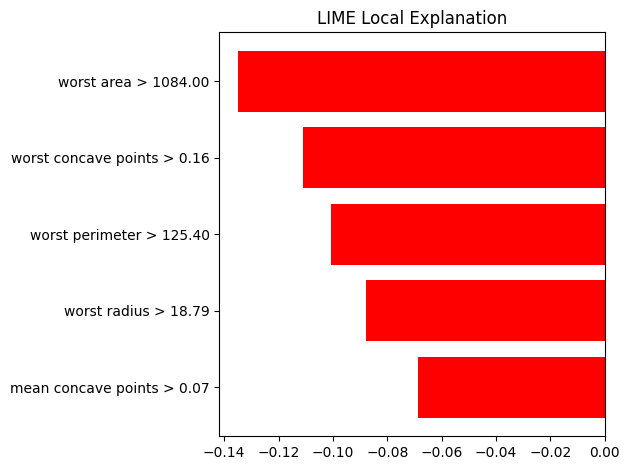

In [ ]:
# Iterate dynamically over each target
all_lime_explanations = {}
for current_target in targets:

    # Update unified payload for the active target
    unified_payload["target"] = df[current_target]
    unified_payload["metadata"]["active_target"] = current_target

    if unified_payload["scope"] in ["local", "both"]:

        # Determine prediction function and mode dynamically based on task type
        if task_type == "classification":
            lime_mode = "classification"
            # Wrapper to retain feature names
            predict_fn = lambda x: model.predict_proba(pd.DataFrame(x, columns=feature_names))
        else:
            lime_mode = "regression"
            # Wrapper to retain feature names
            predict_fn = lambda x: model.predict(pd.DataFrame(x, columns=feature_names))

        # Map categorical column names to integer indices for LimeTabularExplainer
        cat_cols = unified_payload["metadata"]["categorical_features"]
        cat_indices = [feature_names.index(col) for col in cat_cols if col in feature_names]

        # Initialize LIME Tabular Explainer
        lime_explainer = LimeTabularExplainer(
            training_data=X_np,
            feature_names=feature_names,
            categorical_features=cat_indices if len(cat_indices) > 0 else None,
            class_names=unified_payload["metadata"]["class_names"],
            mode=lime_mode,
            random_state=unified_payload["metadata"]["random_state"],
        )
        # Generate Instance Explanation
        exp_lime = lime_explainer.explain_instance(
            data_row=x_1d,
            predict_fn=predict_fn,
            num_features=5
        )

        # 1. Extract Raw Explanation Weights as list
        lime_weights = exp_lime.as_list()

        # Safely extract prediction without feature-name warnings or type errors
        raw_pred = model.predict(pd.DataFrame(x_2d, columns=feature_names))[0]
        predicted_val = float(raw_pred) if isinstance(raw_pred, (int, float)) else str(raw_pred)

        # LLM VALUES OUTPUT?
        # lime_llm_payload = {
        #     "method": "LIME",
        #     "target": current_target,
        #     "predicted_class_or_value": predicted_val,
        #     "feature_contributions": [
        #         {"rule": rule, "weight": float(weight)} for rule, weight in lime_weights
        #     ]
        # }
        # # Store in dictionary
        # all_lime_explanations[current_target] = lime_llm_payload

        print("\n--------------- LIMΕ - Raw Values: ---------------")
        lime_llm_payload = {"target": current_target, "prediction": predicted_val, "rules": dict(exp_lime.as_list())}
        print(lime_llm_payload)

        # 2. Visualize Explanation Output
        print("\n----------------- LIMΕ - Plots: -----------------")
        fig = exp_lime.as_pyplot_figure()
        plt.title("LIME Local Explanation")
        plt.tight_layout()
        plt.show()

        exp_lime.show_in_notebook(
        show_table=True,      # bool (Default: False)
        show_all=False,       # bool (Default: True)
        labels=None,          # Iterable[int] (Default: None)
        predict_proba=(task_type == "classification"),  # Only display probabilities in classification mode
    )

## 3.2 TreeSHAP

### 3.2.1 TreeSHAP Local Explanation

TreeSHAP values shape: (1, 30, 2)

================= TreeSHAP Local - Target: target =================

--------------- Local TreeSHAP - Raw Values: ---------------
{'method': 'TreeSHAP', 'target': 'target', 'base_value': 0.3702401874633861, 'prediction': 0.9947785730374303, 'feature_contributions': [{'feature': 'worst concave points', 'shap_value': 0.11090082611637188}, {'feature': 'worst area', 'shap_value': 0.06728280757754408}, {'feature': 'mean concave points', 'shap_value': 0.060152401766614905}, {'feature': 'worst perimeter', 'shap_value': 0.0590885457325226}, {'feature': 'worst radius', 'shap_value': 0.049319265716138254}, {'feature': 'worst texture', 'shap_value': -0.04659336307988516}, {'feature': 'area error', 'shap_value': 0.04502965405133748}, {'feature': 'mean perimeter', 'shap_value': 0.0445794631830457}, {'feature': 'mean radius', 'shap_value': 0.038458578995494444}, {'feature': 'mean concavity', 'shap_value': 0.03831025723859768}, {'feature': 'mean area', 'shap_value':

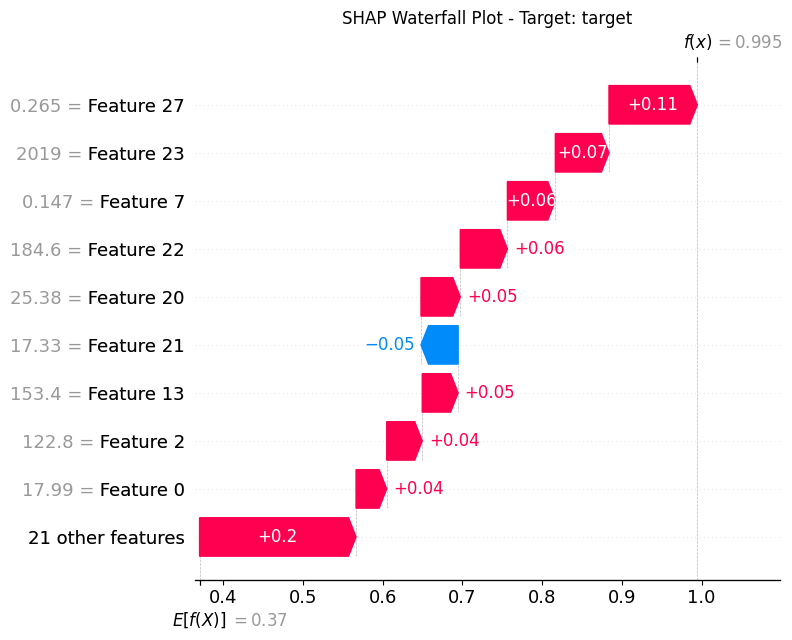

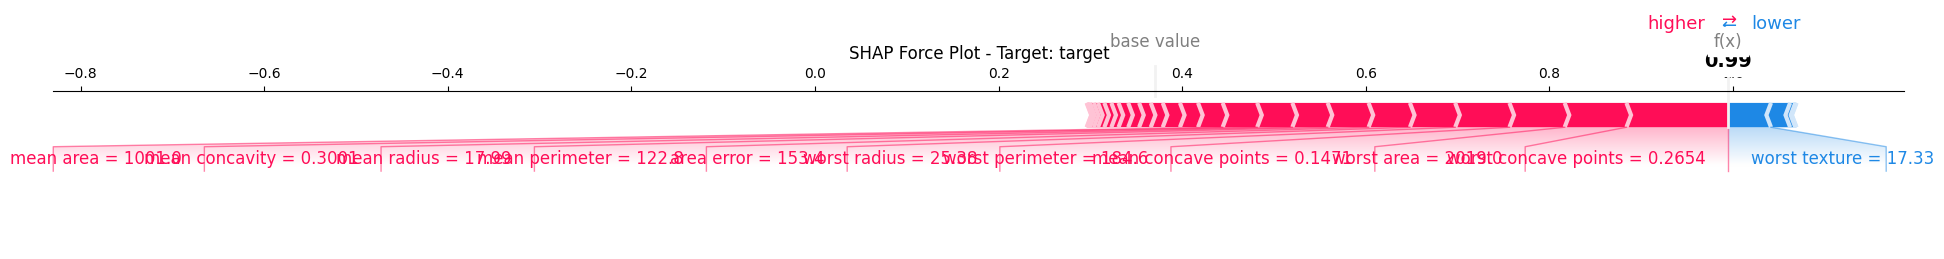

In [ ]:
if unified_payload["scope"] in ["local", "both"]:
  # Initialize TreeSHAP Explainer
  tree_explainer = shap.TreeExplainer(model)
  tree_shap_values = tree_explainer(x_2d)
  print(f'TreeSHAP values shape: {tree_shap_values.values.shape}')

  # Container to collect SHAP values across targets for downstream LLM ingestion
  shap_llm_payload = {}

  # Iterate through targets with their integer index
  for target_idx, current_target in enumerate(targets):

    print(f"\n================= TreeSHAP Local - Target: {current_target} =================")

    # ------------------------- Raw Values Extraction -------------------------

    # Slice Explanation object for the single query instance (0) and specific target/class
    if len(tree_shap_values.values.shape) == 3:
      # Multi-class or multi-target shape: (n_samples, n_features, n_classes)
      exp_instance = tree_shap_values[0, :, target_idx]
    else:
      # Single-target regression shape: (n_samples, n_features)
      exp_instance = tree_shap_values[0]

    shap_vals = exp_instance.values
    base_val = float(exp_instance.base_values)

    # Map each feature to its corresponding SHAP value
    feature_contributions = [
        {"feature": feat, "shap_value": float(val)}
        for feat, val in zip(feature_names, shap_vals)
    ]
    # Sort features by absolute contribution impact
    feature_contributions.sort(key=lambda x: abs(x["shap_value"]), reverse=True)

    shap_llm_payload[current_target] = {
        "method": "TreeSHAP",
        "target": current_target,
        "base_value": base_val,
        "prediction": float(base_val + sum(shap_vals)),
        "feature_contributions": feature_contributions
    }
    # ------------------------- TreeSHAP Local Output -------------------------
    print("\n--------------- Local TreeSHAP - Raw Values: ---------------")
    print(shap_llm_payload[current_target])


    print("\n--------------- Global TreeSHAP - Plots ({current_target}): ---------------")

    # Waterfall Plot
    plt.figure()
    shap.plots.waterfall(exp_instance, show=False)
    plt.title(f"SHAP Waterfall Plot - Target: {current_target}")
    plt.tight_layout()
    plt.show()

    # Interactive Force Plot (JavaScript / D3.js rendering)
    shap.initjs()

    # Force Plot (Rendered via Matplotlib for inline display)
    shap.plots.force(
        base_value=exp_instance.base_values,
        shap_values=exp_instance.values,
        features=exp_instance.data,
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    plt.title(f"SHAP Force Plot - Target: {current_target}")
    plt.tight_layout()
    plt.show()



### 3.2.2 TreeSHAP Global Explanation

Global TreeSHAP values shape: (569, 30, 2)

================= TreeSHAP Global - Target: target =================

--------------- Global TreeSHAP - Raw Values: ---------------
{'method': 'TreeSHAP_Global', 'output_label': 'malignant', 'feature_importance': [{'feature': 'worst concave points', 'mean_abs_shap': 0.06938098148911695}, {'feature': 'mean concave points', 'mean_abs_shap': 0.05692423802446552}, {'feature': 'worst area', 'mean_abs_shap': 0.04571328551046104}, {'feature': 'worst perimeter', 'mean_abs_shap': 0.04355599399778138}, {'feature': 'worst radius', 'mean_abs_shap': 0.03549906160748622}, {'feature': 'mean area', 'mean_abs_shap': 0.034683829150841235}, {'feature': 'mean concavity', 'mean_abs_shap': 0.03396280624643414}, {'feature': 'mean perimeter', 'mean_abs_shap': 0.02961003309593816}, {'feature': 'mean radius', 'mean_abs_shap': 0.027217338341737705}, {'feature': 'area error', 'mean_abs_shap': 0.023452468340910932}, {'feature': 'worst concavity', 'mean_abs_shap': 0.02010

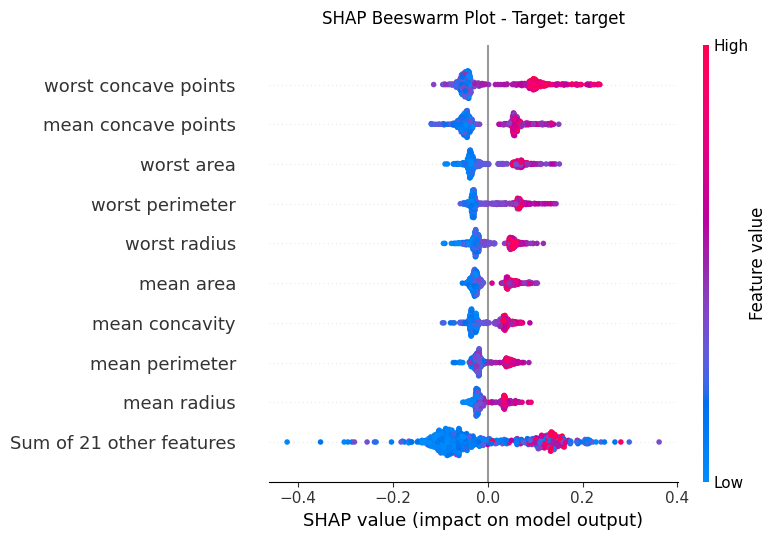

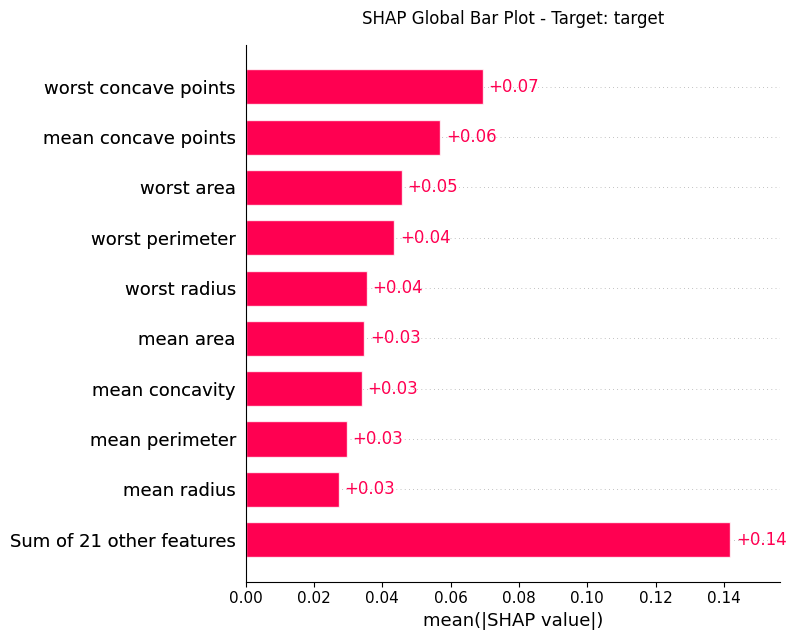

<Figure size 640x480 with 0 Axes>

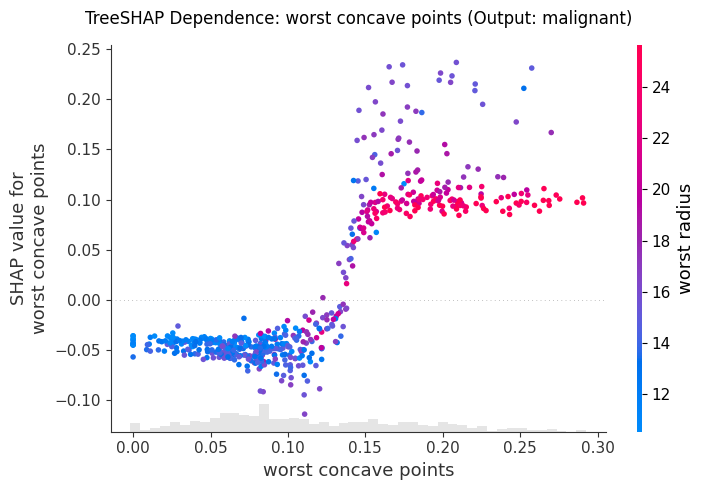


================= TreeSHAP Global - Target: target =================

--------------- Global TreeSHAP - Raw Values: ---------------
{'method': 'TreeSHAP_Global', 'output_label': 'benign', 'feature_importance': [{'feature': 'worst concave points', 'mean_abs_shap': 0.06938098148911698}, {'feature': 'mean concave points', 'mean_abs_shap': 0.05692423802446551}, {'feature': 'worst area', 'mean_abs_shap': 0.045713285510461034}, {'feature': 'worst perimeter', 'mean_abs_shap': 0.04355599399778139}, {'feature': 'worst radius', 'mean_abs_shap': 0.03549906160748621}, {'feature': 'mean area', 'mean_abs_shap': 0.03468382915084123}, {'feature': 'mean concavity', 'mean_abs_shap': 0.033962806246434135}, {'feature': 'mean perimeter', 'mean_abs_shap': 0.02961003309593816}, {'feature': 'mean radius', 'mean_abs_shap': 0.027217338341737715}, {'feature': 'area error', 'mean_abs_shap': 0.023452468340910925}, {'feature': 'worst concavity', 'mean_abs_shap': 0.020109256402578542}, {'feature': 'worst texture', 

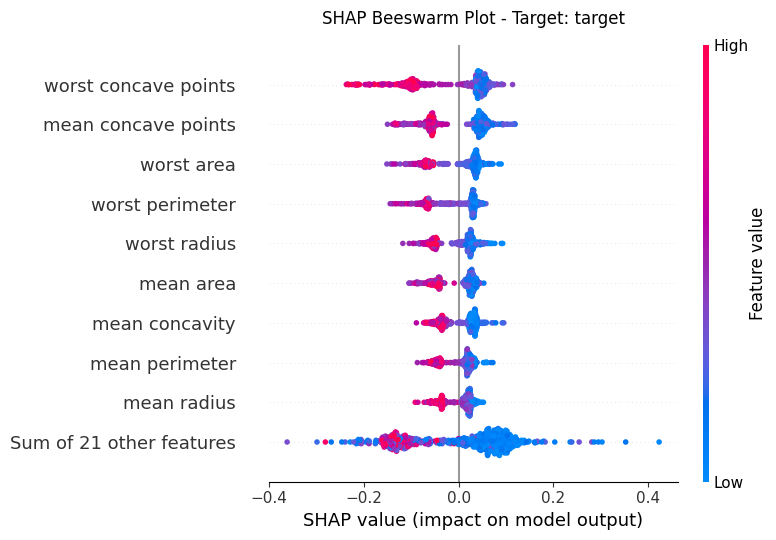

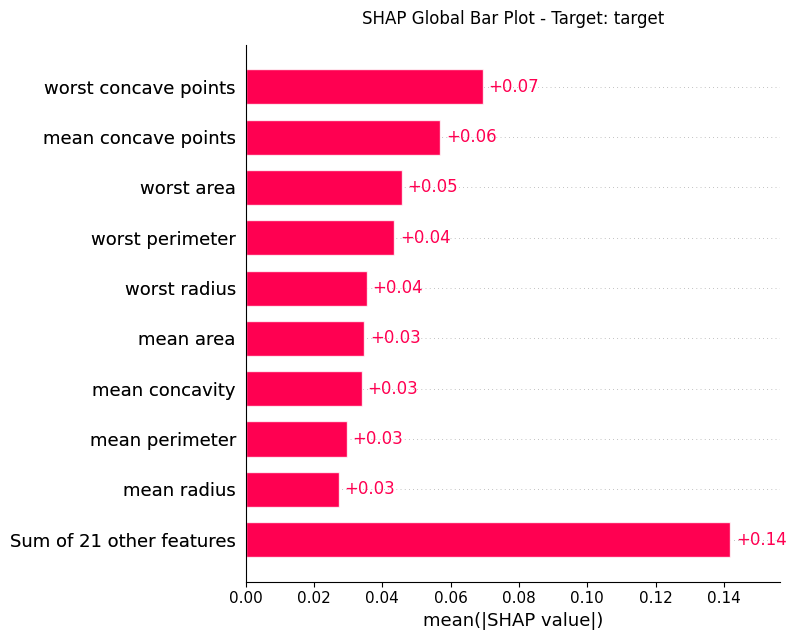

<Figure size 640x480 with 0 Axes>

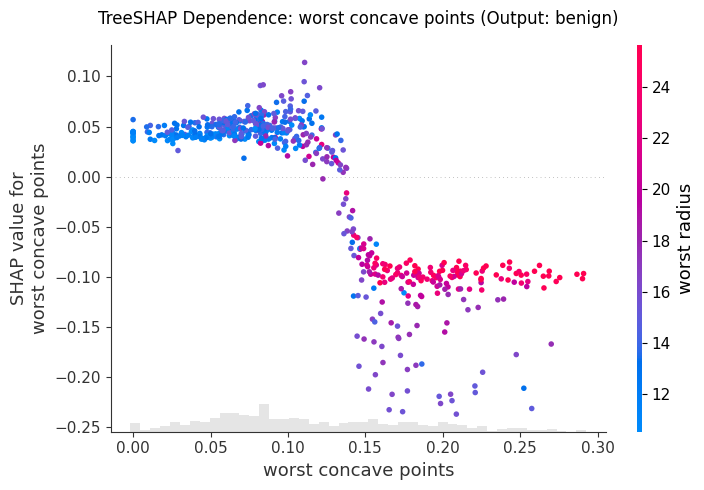

In [ ]:
if unified_payload["scope"] in ["global", "both"]:

    # Compute TreeSHAP Explanation across the entire reference dataset (or sample)
    tree_explainer = shap.TreeExplainer(model)
    tree_shap_values_global = tree_explainer(df_ref)
    print(f"Global TreeSHAP values shape: {tree_shap_values_global.values.shape}")

    # Resolve dynamic output labels (classes for classification, targets for regression)
    if task_type == "classification":
        # Extract class names from metadata or fallback to numeric class indices
        output_labels = unified_payload["metadata"].get("class_names")
        if output_labels is None:
            n_classes = tree_shap_values_global.values.shape[-1] if len(tree_shap_values_global.values.shape) == 3 else 2
            output_labels = [f"Class_{i}" for i in range(n_classes)]
    else:
        # Regression: target names (handles both single target string and list of targets)
        output_labels = targets if isinstance(targets, list) else [targets]

    # Container to collect global SHAP feature importances for downstream LLM
    tshap_global_llm_payload = {}

    # Iterate over resolved output labels
    for out_idx, current_label in enumerate(output_labels):

        print(f"\n================= TreeSHAP Global - Target: {current_target} =================")

        # Slice Explanation object safely for current output
        if len(tree_shap_values_global.values.shape) == 3:
            # 3D Array: (n_samples, n_features, n_classes/targets) -> Slice to 2D
            exp_global = tree_shap_values_global[:, :, out_idx]
        else:
            # 2D Array: Single-target regression
            exp_global = tree_shap_values_global

        # ------------------------- TreeSHAP Raw Values Extraction -------------------------

        # TreeSHAP Global Feature Importance extraction for LLM
        mean_abs_shap = np.mean(np.abs(exp_global.values), axis=0)
        global_contributions = [
            {"feature": feat, "mean_abs_shap": float(val)}
            for feat, val in zip(feature_names, mean_abs_shap)
        ]
        global_contributions.sort(key=lambda x: x["mean_abs_shap"], reverse=True)

        tshap_global_llm_payload[str(current_label)] = {
            "method": "TreeSHAP_Global",
            "output_label": str(current_label),
            "feature_importance": global_contributions
        }

        print("\n--------------- Global TreeSHAP - Raw Values: ---------------")
        print(tshap_global_llm_payload[str(current_label)])

        # ------------------------- TreeSHAP Gloabl Output -------------------------
        print(f"\n--------------- Global TreeSHAP - Plots ({current_target}): ---------------")

        # TreeSHAP Beeswarm / Summary Plot
        plt.figure()
        shap.plots.beeswarm(exp_global, show=False)
        plt.title(f"SHAP Beeswarm Plot - Target: {current_target}", pad=15)
        plt.tight_layout()
        plt.show()

        # TreeSHAP Global Feature Importance Bar Plot
        plt.figure()
        shap.plots.bar(exp_global, show=False)
        plt.title(f"SHAP Global Bar Plot - Target: {current_target}", pad=15)
        plt.tight_layout()
        plt.show()

        # TreeSHAP Global Dynamic Dependence Plot (Top Feature)
        top_feature = global_contributions[0]["feature"]
        plt.figure()
        shap.plots.scatter(
            exp_global[:, top_feature],   # Strictly 1D slice
            color=exp_global,             # 2D slice for interaction color
            show=False
        )

        plt.title(f"TreeSHAP Dependence: {top_feature} (Output: {current_label})", pad=15)
        plt.tight_layout()
        plt.show()

## 3.3 KernelSHAP

### 3.3.1 KernelSHAP Local Explanation

  0%|          | 0/1 [00:00<?, ?it/s]

KernelSHAP values shape: (1, 30, 2)

================= KernelSHAP Local - Output: malignant =================

--------------- Local KernelSHAP - Raw Values: ---------------
{'method': 'KernelSHAP', 'target': 'malignant', 'base_value': 0.3919133933179485, 'prediction': 0.9947785730374303, 'feature_contributions': [{'feature': 'worst concave points', 'shap_value': 0.11638153059221548}, {'feature': 'worst perimeter', 'shap_value': 0.07820975706364283}, {'feature': 'mean area', 'shap_value': 0.06317285247529651}, {'feature': 'worst area', 'shap_value': 0.06234344187646485}, {'feature': 'area error', 'shap_value': 0.06000309204941612}, {'feature': 'mean concavity', 'shap_value': 0.056242130650862365}, {'feature': 'mean concave points', 'shap_value': 0.05424168500235145}, {'feature': 'worst radius', 'shap_value': 0.04389784308741555}, {'feature': 'perimeter error', 'shap_value': 0.04363960631048826}, {'feature': 'mean radius', 'shap_value': 0.024733240611328422}, {'feature': 'mean texture',

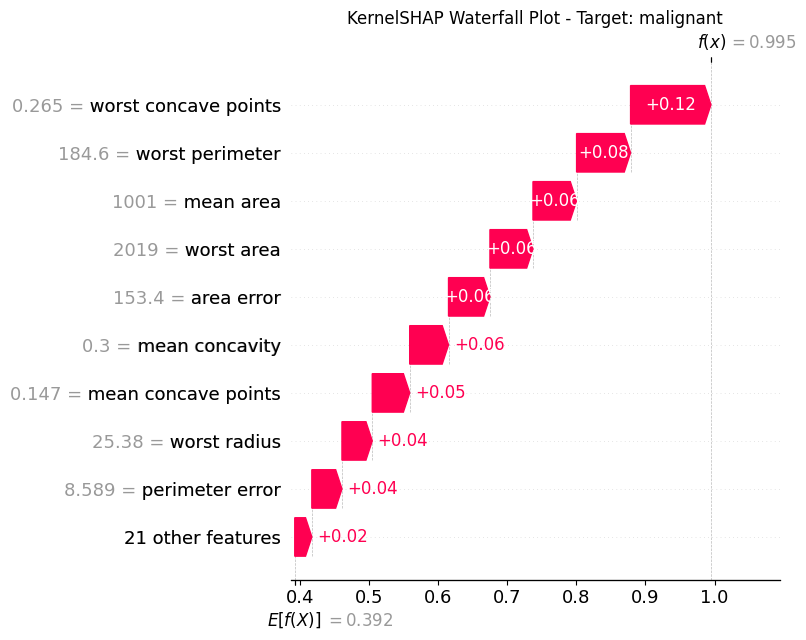

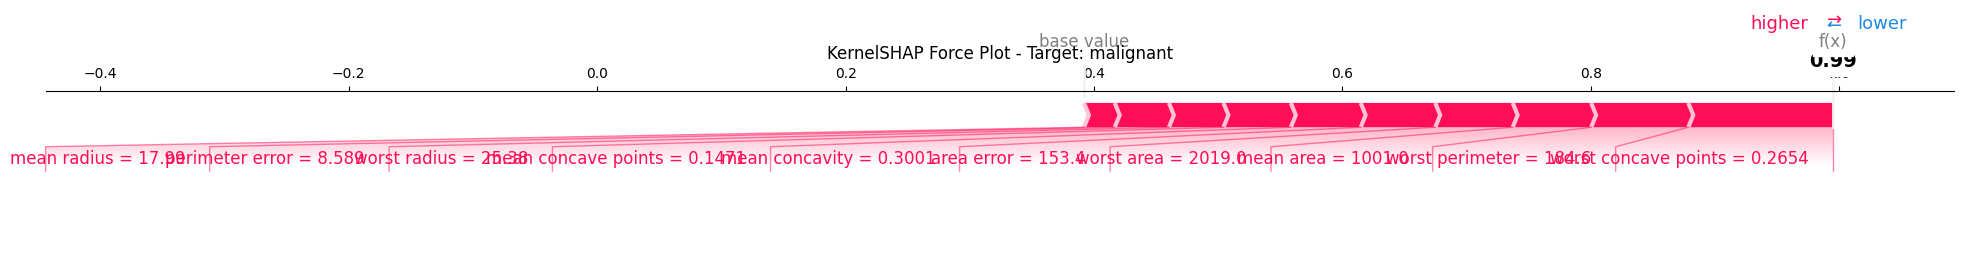


================= KernelSHAP Local - Output: benign =================

--------------- Local KernelSHAP - Raw Values: ---------------
{'method': 'KernelSHAP', 'target': 'benign', 'base_value': 0.3919133933179485, 'prediction': -0.2109517864015329, 'feature_contributions': [{'feature': 'worst concave points', 'shap_value': -0.11638153059221526}, {'feature': 'worst perimeter', 'shap_value': -0.07820975706364275}, {'feature': 'mean area', 'shap_value': -0.06317285247529653}, {'feature': 'worst area', 'shap_value': -0.06234344187646503}, {'feature': 'area error', 'shap_value': -0.060003092049416104}, {'feature': 'mean concavity', 'shap_value': -0.05624213065086221}, {'feature': 'mean concave points', 'shap_value': -0.05424168500235139}, {'feature': 'worst radius', 'shap_value': -0.04389784308741557}, {'feature': 'perimeter error', 'shap_value': -0.043639606310488174}, {'feature': 'mean radius', 'shap_value': -0.024733240611328422}, {'feature': 'mean texture', 'shap_value': 0.0}, {'feature

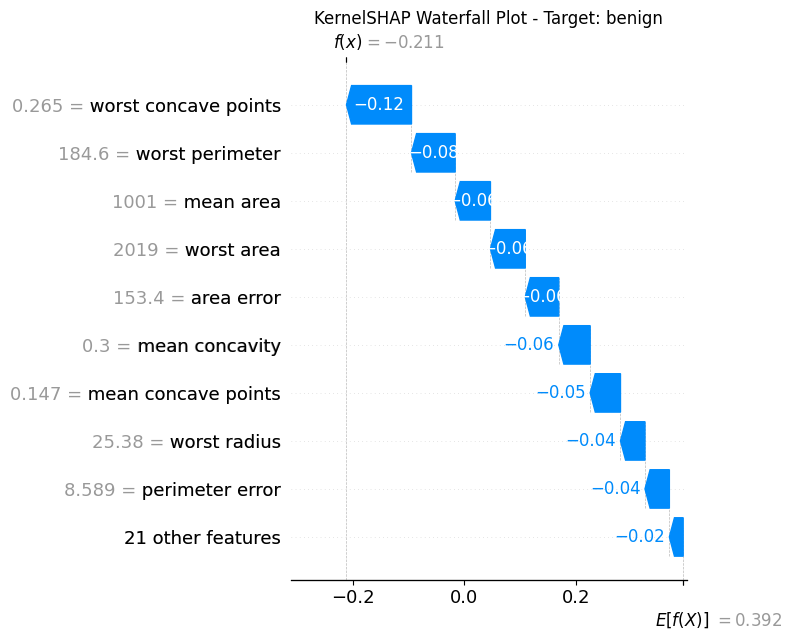

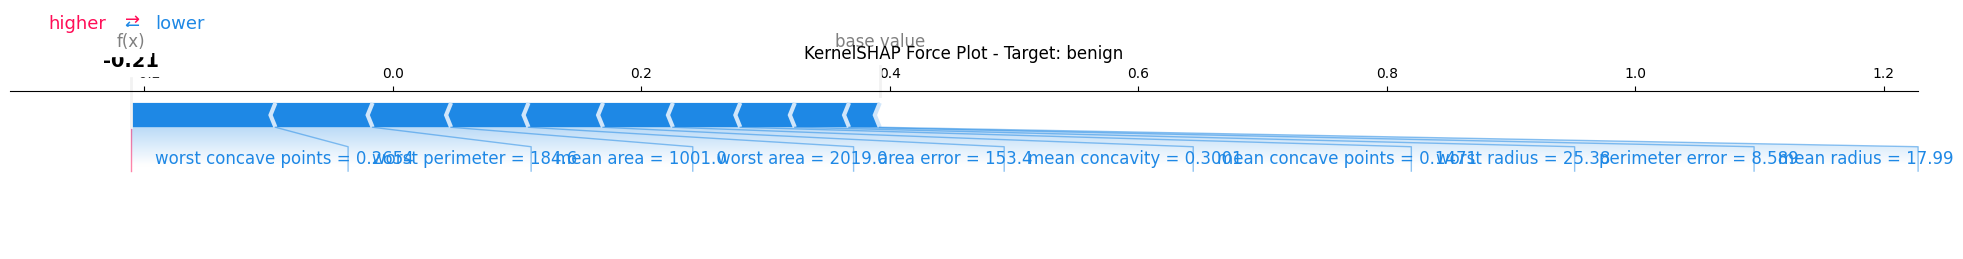

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

if unified_payload['scope'] in ['local', 'both']:
    # 1. Background data summary (50 samples for speed)
    background_data = shap.sample(df_ref, 50)

    # 2. Select prediction function dynamically
    predict_fn = model.predict_proba if task_type == 'classification' else model.predict

    # 3. Direct KernelExplainer initialization
    # Wrapped with lambda to guarantee DataFrame input with feature names
    kernel_explainer = shap.KernelExplainer(
        lambda x: predict_fn(pd.DataFrame(x, columns=feature_names)),
        background_data
    )

    # Compute raw shap values
    raw_shap_values = kernel_explainer.shap_values(
        pd.DataFrame(x_2d, columns=feature_names),
        nsamples=100
    )

    # 4. Wrap raw values into a native shap.Explanation object
    expected_val = kernel_explainer.expected_value

    # Convert list output (multiclass) to 3D array: (n_instances, n_features, n_classes)
    if isinstance(raw_shap_values, list):
        stacked_values = np.stack(raw_shap_values, axis=-1)
        expected_val = np.array(expected_val)
    else:
        stacked_values = np.array(raw_shap_values)

    kernel_shap_values = shap.Explanation(
        values=stacked_values,
        base_values=expected_val,
        data=x_2d,
        feature_names=feature_names
    )
    print(f'KernelSHAP values shape: {kernel_shap_values.values.shape}')

    # Resolve labels dynamically (classes for classification, targets for regression)
    if task_type == 'classification':
        output_labels = unified_payload['metadata'].get('class_names')
        if output_labels is None:
            n_classes = kernel_shap_values.values.shape[-1] if len(kernel_shap_values.values.shape) == 3 else 2
            output_labels = [f"Class_{i}" for i in range(n_classes)]
    else:
        output_labels = targets if isinstance(targets, list) else [targets]

    # Container to collect SHAP values across targets/classes for LLM ingestion
    kshap_llm_payload = {}

    # Iterate through outputs
    for target_idx, current_target in enumerate(output_labels):

        print(f"\n================= KernelSHAP Local - Output: {current_target} =================")

        # ------------------------- Raw Values Extraction -------------------------
        # Slice Explanation object for the single query instance (0) and specific class/target
        if len(kernel_shap_values.values.shape) == 3:
            exp_instance = kernel_shap_values[0, :, target_idx]
        else:
            exp_instance = kernel_shap_values[0]

        shap_vals = exp_instance.values
        base_val = float(exp_instance.base_values)

        feature_contributions = [
            {"feature": feat, "shap_value": float(val)}
            for feat, val in zip(feature_names, shap_vals)
        ]
        feature_contributions.sort(key=lambda x: abs(x["shap_value"]), reverse=True)

        kshap_llm_payload[str(current_target)] = {
            "method": "KernelSHAP",
            "target": str(current_target),
            "base_value": base_val,
            "prediction": float(base_val + sum(shap_vals)),
            "feature_contributions": feature_contributions
        }

        # ------------------------- KernelSHAP Local Output -------------------------
        print("\n--------------- Local KernelSHAP - Raw Values: ---------------")
        print(kshap_llm_payload[str(current_target)])

        print(f"\n--------------- Local KernelSHAP - Plots ({current_target}): ---------------")

        # KernelSHAP Waterfall Plot
        plt.figure()
        shap.plots.waterfall(exp_instance, show=False)
        plt.title(f"KernelSHAP Waterfall Plot - Target: {current_target}")
        plt.tight_layout()
        plt.show()

        # KernelSHAP Force Plot (Matplotlib version for inline/script export)
        shap.plots.force(
            base_value=exp_instance.base_values,
            shap_values=exp_instance.values,
            features=exp_instance.data,
            feature_names=feature_names,
            matplotlib=True,
            show=False
        )
        plt.title(f"KernelSHAP Force Plot - Target: {current_target}")
        plt.tight_layout()
        plt.show()

### 3.3.2 KernelSHAP Global Explanation

  0%|          | 0/100 [00:00<?, ?it/s]

Global KernelSHAP values shape: (100, 30, 2)

================= KernelSHAP Global - Output: malignant =================

--------------- Global KernelSHAP - Raw Values: ---------------
{'method': 'KernelSHAP_Global', 'output_label': 'malignant', 'feature_importance': [{'feature': 'worst area', 'mean_abs_shap': 0.0698543001683392}, {'feature': 'mean concave points', 'mean_abs_shap': 0.057854767508521726}, {'feature': 'worst concave points', 'mean_abs_shap': 0.057432700655484885}, {'feature': 'worst perimeter', 'mean_abs_shap': 0.051099930155729875}, {'feature': 'worst radius', 'mean_abs_shap': 0.043535830292679184}, {'feature': 'mean area', 'mean_abs_shap': 0.032392099288123526}, {'feature': 'mean concavity', 'mean_abs_shap': 0.023021018180404137}, {'feature': 'mean radius', 'mean_abs_shap': 0.01826674943691079}, {'feature': 'area error', 'mean_abs_shap': 0.01730315730437576}, {'feature': 'worst concavity', 'mean_abs_shap': 0.01496504730405475}, {'feature': 'mean perimeter', 'mean_abs_s

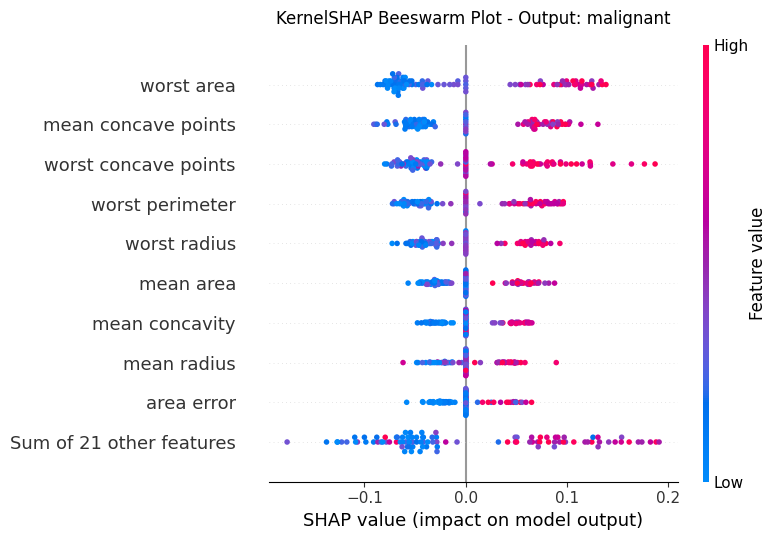

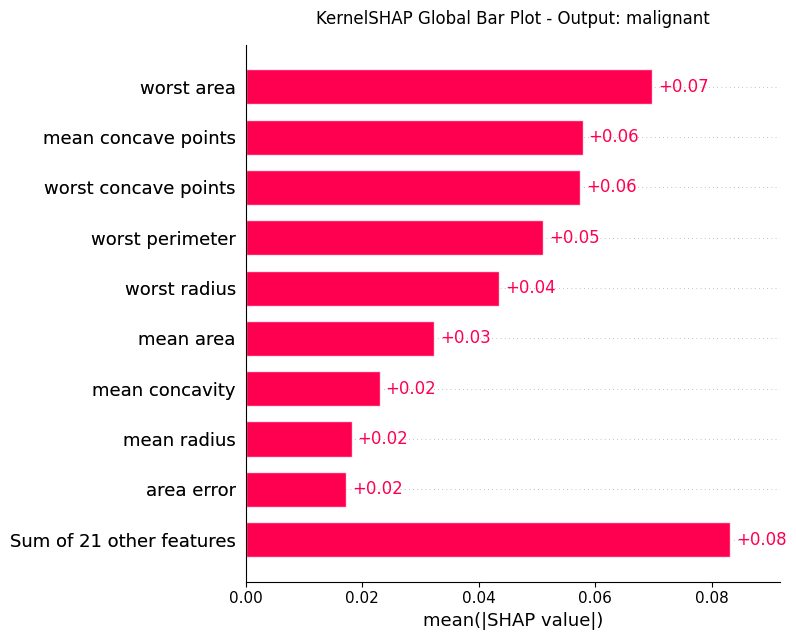

<Figure size 640x480 with 0 Axes>

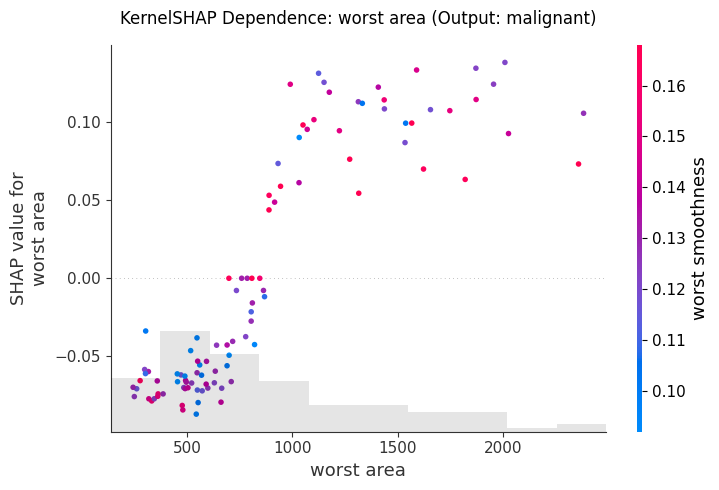


================= KernelSHAP Global - Output: benign =================

--------------- Global KernelSHAP - Raw Values: ---------------
{'method': 'KernelSHAP_Global', 'output_label': 'benign', 'feature_importance': [{'feature': 'worst area', 'mean_abs_shap': 0.0698543001683392}, {'feature': 'mean concave points', 'mean_abs_shap': 0.05785476750852173}, {'feature': 'worst concave points', 'mean_abs_shap': 0.057432700655484885}, {'feature': 'worst perimeter', 'mean_abs_shap': 0.05109993015572982}, {'feature': 'worst radius', 'mean_abs_shap': 0.04353583029267919}, {'feature': 'mean area', 'mean_abs_shap': 0.03239209928812353}, {'feature': 'mean concavity', 'mean_abs_shap': 0.02302101818040413}, {'feature': 'mean radius', 'mean_abs_shap': 0.018266749436910788}, {'feature': 'area error', 'mean_abs_shap': 0.017303157304375757}, {'feature': 'worst concavity', 'mean_abs_shap': 0.01496504730405475}, {'feature': 'mean perimeter', 'mean_abs_shap': 0.01364469078748614}, {'feature': 'worst texture

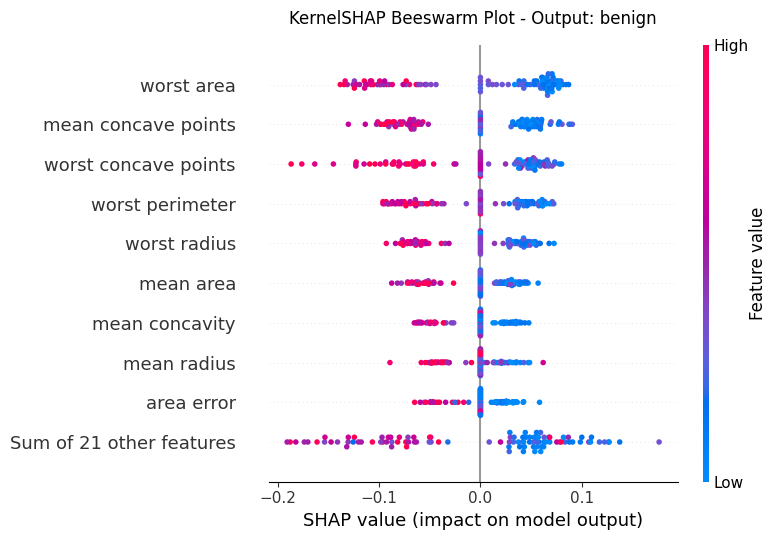

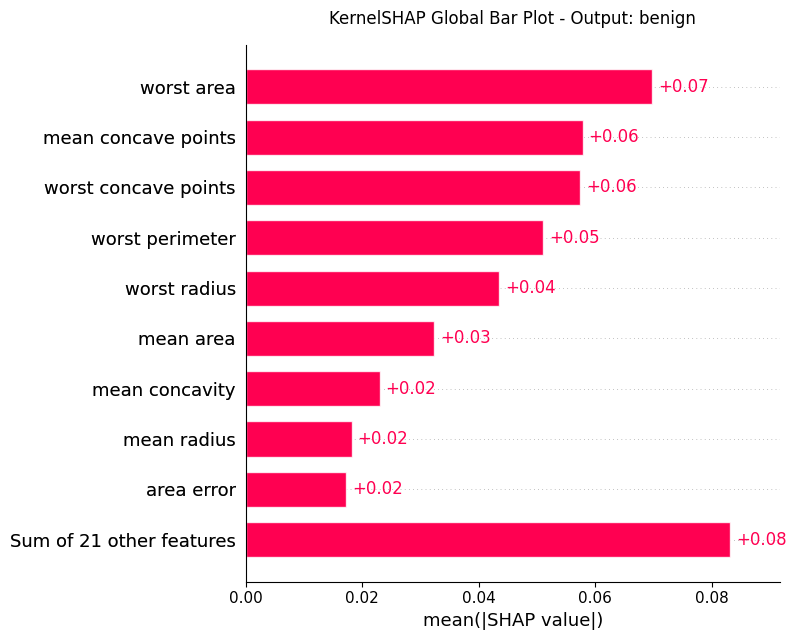

<Figure size 640x480 with 0 Axes>

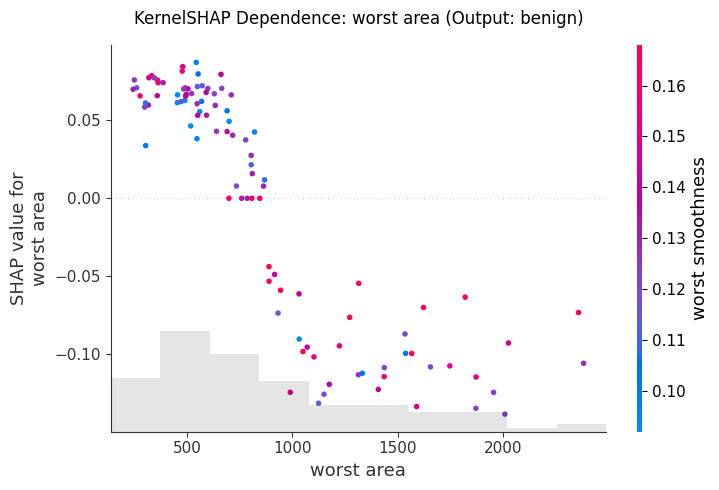

In [ ]:
if unified_payload["scope"] in ["global", "both"]:

    # 1. Background Summary (Reference baseline for perturbation)
    background_data = shap.sample(df_ref, 50)

    # 2. Evaluation Sample (KernelSHAP is too slow for entire dataset)
    n_eval_samples = min(100, len(df_ref))
    df_eval = shap.sample(df_ref, n_eval_samples)

    # 3. Select prediction function dynamically
    predict_fn = model.predict_proba if task_type == "classification" else model.predict

    # 4. Initialize KernelExplainer
    kernel_explainer = shap.KernelExplainer(
        lambda x: predict_fn(pd.DataFrame(x, columns=feature_names)),
        background_data
    )

    # Compute raw SHAP values across evaluation instances
    raw_shap_values = kernel_explainer.shap_values(
        pd.DataFrame(df_eval, columns=feature_names),
        nsamples=100
    )

    # 5. Pack raw values into a native shap.Explanation object
    expected_val = kernel_explainer.expected_value

    if isinstance(raw_shap_values, list):
        # Multi-class output: stack to shape (n_samples, n_features, n_classes)
        stacked_values = np.stack(raw_shap_values, axis=-1)
        expected_val = np.array(expected_val)
    else:
        # Single-target regression or binary array
        stacked_values = np.array(raw_shap_values)

    kernel_shap_values_global = shap.Explanation(
        values=stacked_values,
        base_values=expected_val,
        data=df_eval.values if hasattr(df_eval, "values") else df_eval,
        feature_names=feature_names
    )
    print(f"Global KernelSHAP values shape: {kernel_shap_values_global.values.shape}")

    # Resolve dynamic output labels (classes for classification, targets for regression)
    if task_type == "classification":
        output_labels = unified_payload["metadata"].get("class_names")
        if output_labels is None:
            n_classes = kernel_shap_values_global.values.shape[-1] if len(kernel_shap_values_global.values.shape) == 3 else 2
            output_labels = [f"Class_{i}" for i in range(n_classes)]
    else:
        output_labels = targets if isinstance(targets, list) else [targets]

    # Container to collect global SHAP feature importances for downstream LLM
    kshap_global_llm_payload = {}

    # Iterate over resolved output labels
    for out_idx, current_label in enumerate(output_labels):

        print(f"\n================= KernelSHAP Global - Output: {current_label} =================")

        # Slice Explanation object safely for current output
        if len(kernel_shap_values_global.values.shape) == 3:
            # 3D Array: (n_samples, n_features, n_classes/targets) -> Slice to 2D
            exp_global = kernel_shap_values_global[:, :, out_idx]
        else:
            # 2D Array: Single-target regression
            exp_global = kernel_shap_values_global

        # ------------------------- KernelSHAP Raw Values Extraction -------------------------
        mean_abs_shap = np.mean(np.abs(exp_global.values), axis=0)
        global_contributions = [
            {"feature": feat, "mean_abs_shap": float(val)}
            for feat, val in zip(feature_names, mean_abs_shap)
        ]
        global_contributions.sort(key=lambda x: x["mean_abs_shap"], reverse=True)

        kshap_global_llm_payload[str(current_label)] = {
            "method": "KernelSHAP_Global",
            "output_label": str(current_label),
            "feature_importance": global_contributions
        }

        print("\n--------------- Global KernelSHAP - Raw Values: ---------------")
        print(kshap_global_llm_payload[str(current_label)])

        # ------------------------- KernelSHAP Global Output Plots -------------------------
        print(f"\n--------------- Global KernelSHAP - Plots ({current_label}): ---------------")

        # 1. Beeswarm / Summary Plot
        plt.figure()
        shap.plots.beeswarm(exp_global, show=False)
        plt.title(f"KernelSHAP Beeswarm Plot - Output: {current_label}", pad=15)
        plt.tight_layout()
        plt.show()

        # 2. Global Feature Importance Bar Plot
        plt.figure()
        shap.plots.bar(exp_global, show=False)
        plt.title(f"KernelSHAP Global Bar Plot - Output: {current_label}", pad=15)
        plt.tight_layout()
        plt.show()

        # 3. Dynamic Dependence Plot (Top Feature)
        top_feature = global_contributions[0]["feature"]
        plt.figure()
        shap.plots.scatter(
            exp_global[:, top_feature],   # Strictly 1D slice
            color=exp_global,             # 2D slice for auto interaction detection
            show=False
        )
        plt.title(f"KernelSHAP Dependence: {top_feature} (Output: {current_label})", pad=15)
        plt.tight_layout()
        plt.show()

## 3.4 Counterfactual (DiCE) Local Explanation


================ Target: target (Index: 0) ================


100%|██████████| 1/1 [00:00<00:00,  1.96it/s]



--------------- Counterfactuals Payload (target) ---------------
{'method': 'DiCE_Counterfactuals', 'target': 'target', 'target_index': 0, 'predicted_value': 0.0, 'desired_target': 'opposite', 'counterfactuals': [{'cf_index': 1, 'target_prediction': 1.0, 'modifications': {'mean concave points': {'from': 0.1471, 'to': 0.0, 'delta': -0.1471}, 'worst radius': {'from': 25.38, 'to': 10.23, 'delta': -15.149999999999999}, 'worst perimeter': {'from': 184.6, 'to': 66.8, 'delta': -117.8}, 'worst smoothness': {'from': 0.1622, 'to': 0.0836, 'delta': -0.07860000000000002}, 'worst concave points': {'from': 0.2654, 'to': 0.0, 'delta': -0.2654}, 'worst fractal dimension': {'from': 0.1189, 'to': 0.06751, 'delta': -0.051390000000000005}}, 'full_features': {'mean radius': 17.99, 'mean texture': 10.38, 'mean perimeter': 122.8, 'mean area': 1001.0, 'mean smoothness': 0.1184, 'mean compactness': 0.2776, 'mean concavity': 0.3001, 'mean concave points': 0.0, 'mean symmetry': 0.2419, 'mean fractal dimension':

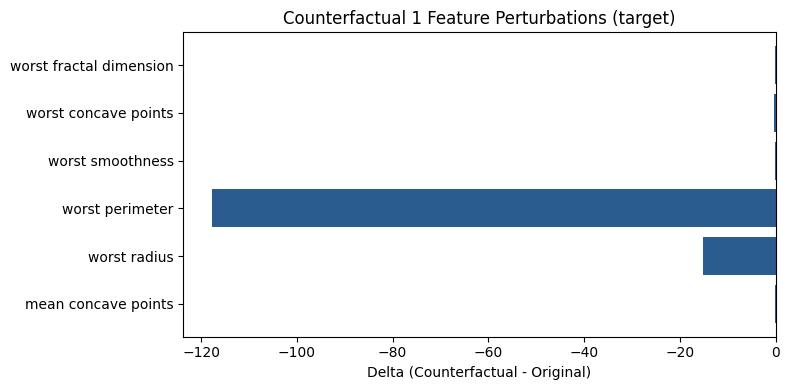

Query instance (original outcome : 0)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.800003,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,17.33,184.600006,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0



Diverse Counterfactual set (new outcome: 1)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,-,-,-,-,-,-,-,0.0,-,-,...,-,66.8,-,0.0836,-,-,0.0,-,0.06751,1.0
1,-,-,-,-,-,-,-,-,0.1141,-,...,13.55,-,351.5,0.0774,-,-,0.0,-,-,1.0
2,-,-,46.19,-,-,0.0248,-,0.0,-,-,...,-,-,-,0.0737,-,-,-,-,-,1.0


In [ ]:
all_cf_explanations = {}

for target_idx, current_target in enumerate(targets):
    # Print distinct header per target
    print(f"\n================ Target: {current_target} (Index: {target_idx}) ================")

    # Update unified payload for the active target
    unified_payload["target"] = df[current_target]
    unified_payload["metadata"]["active_target"] = current_target

    if unified_payload["scope"] in ["local", "both"]:
        # 1. Reuse existing dataframe slice and identify continuous features
        df_dice_train = df[feature_names + [current_target]]
        cat_cols = unified_payload["metadata"].get("categorical_features", [])
        continuous_features = [col for col in feature_names if col not in cat_cols]

        # 2. Setup active model using a simple if statement
        if len(targets) == 1:
            active_model = model
        else:
            from types import SimpleNamespace
            active_model = SimpleNamespace(
                predict=lambda X: (
                    model.predict(X)[:, target_idx]
                    if getattr(model.predict(X), "ndim", 1) > 1
                    else model.predict(X)
                ),
                predict_proba=lambda X: (
                    model.predict_proba(X)[target_idx]
                    if isinstance(model.predict_proba(X), list)
                    else model.predict_proba(X)
                ) if hasattr(model, "predict_proba") else None
            )

        # 3. Initialize DiCE data and model objects
        d_dice = dice_ml.Data(
            dataframe=df_dice_train,
            continuous_features=continuous_features,
            outcome_name=current_target,
        )
        m_dice = dice_ml.Model(
            model=active_model,
            backend="sklearn",
            model_type="classifier" if task_type == "classification" else "regressor",
        )
        exp_dice = dice_ml.Dice(d_dice, m_dice, method="random")

        # 4. Prepare single query instance as DataFrame
        query_instance = pd.DataFrame(x_2d, columns=feature_names)

        # Extract current prediction
        raw_pred = active_model.predict(query_instance)[0]
        predicted_val = float(raw_pred) if isinstance(raw_pred, (int, float, np.number)) else str(raw_pred)

        # 5. Configure counterfactual targets
        cf_kwargs = {
            "query_instances": query_instance,
            "total_CFs": 3,
            "features_to_vary": "all",
            "random_seed": unified_payload["metadata"].get("random_state", 42),
        }

        if task_type == "classification":
            classes = unified_payload["metadata"].get("class_names", [0, 1])
            cf_kwargs["desired_class"] = "opposite" if len(classes) == 2 else (1 if raw_pred == 0 else 0)
        else:
            cf_kwargs["desired_range"] = [float(predicted_val) * 1.05, float(predicted_val) * 1.50]

        # 6. Generate explanations and extract results
        dice_exp = exp_dice.generate_counterfactuals(**cf_kwargs)
        cf_df = dice_exp.cf_examples_list[0].final_cfs_df

        # 7. Build structured LLM payload with explicit feature deltas
        orig_dict = query_instance.iloc[0].to_dict()
        cf_llm_payload = {
            "method": "DiCE_Counterfactuals",
            "target": current_target,
            "target_index": target_idx,
            "predicted_value": predicted_val,
            "desired_target": cf_kwargs.get("desired_class", cf_kwargs.get("desired_range")),
            "counterfactuals": [],
        }

        if cf_df is not None and not cf_df.empty:
            for idx, row in cf_df.iterrows():
                cf_row = row.to_dict()
                cf_target_val = cf_row.pop(current_target, None)
                modifications = {}

                for col, orig_val in orig_dict.items():
                    new_val = cf_row.get(col)
                    if isinstance(orig_val, (int, float, np.number)) and isinstance(new_val, (int, float, np.number)):
                        if not np.isclose(orig_val, new_val, atol=1e-4):
                            modifications[col] = {
                                "from": float(orig_val),
                                "to": float(new_val),
                                "delta": float(new_val - orig_val),
                            }
                    elif orig_val != new_val:
                        modifications[col] = {"from": orig_val, "to": new_val}

                cf_llm_payload["counterfactuals"].append({
                    "cf_index": idx + 1,
                    "target_prediction": float(cf_target_val) if isinstance(cf_target_val, (int, float, np.number)) else str(cf_target_val),
                    "modifications": modifications,
                    "full_features": cf_row,
                })

        all_cf_explanations[current_target] = cf_llm_payload

        # 8. Print raw values and visualize
        print(f"\n--------------- Counterfactuals Payload ({current_target}) ---------------")
        print(cf_llm_payload)

        print(f"\n----------------- Counterfactuals Plots ({current_target}) -----------------")
        if cf_df is not None and not cf_df.empty:
            # Bar plot of feature deltas for CF 1
            first_cfs = cf_llm_payload["counterfactuals"][0]["modifications"]
            if first_cfs:
                feats = list(first_cfs.keys())
                deltas = [m.get("delta", 0.0) if "delta" in m else 1.0 for m in first_cfs.values()]

                plt.figure(figsize=(8, 4))
                plt.barh(feats, deltas, color="#2b5c8f")
                plt.xlabel("Delta (Counterfactual - Original)")
                plt.title(f"Counterfactual 1 Feature Perturbations ({current_target})")
                plt.tight_layout()
                plt.savefig(f"cf_deltas_{current_target}.png", dpi=300)
                plt.show()

            # Display formatted table of changes
            dice_exp.visualize_as_dataframe(show_only_changes=True)

## 3.5 Anchors

In [ ]:
# Iterate dynamically over each target
anchors_explanations = {}
for current_target in targets:

    # Update unified payload for the active target
    unified_payload["target"] = df[current_target]
    unified_payload["metadata"]["active_target"] = current_target

    if unified_payload["scope"] in ["local", "both"]:

        # Determine prediction function and mode dynamically based on task type
        if task_type == "classification":
            # Wrapper to retain feature names
            predict_fn = lambda x: model.predict(pd.DataFrame(x, columns=feature_names))
        else:
            raise NotImplementedError("The Anchors method is exclusively applicable to classification tasks.")

        # Map categorical column names to integer indices for AnchorTabularExplainer
        cat_cols = unified_payload["metadata"]["categorical_features"]
        cat_indices = [feature_names.index(col) for col in cat_cols if col in feature_names]

        categorical_names = (
            {idx: list(np.unique(X_np[:, idx])) for idx in cat_indices}
            if cat_indices else {}
        )

        # Initialize Anchor Tabular Explainer
        explainer = anchor_tabular.AnchorTabularExplainer(
            class_names=unified_payload["metadata"]["class_names"],
            feature_names=feature_names,
            train_data=X_np,
            categorical_names=categorical_names
        )

        exp = explainer.explain_instance(
            data_row=x_1d,
            classifier_fn=predict_fn,
            threshold=0.95,
            verbose=True
        )

        print("Anchor Rule:", " AND ".join(exp.names()))
        print(f"Precision: {exp.precision():.2f}")
        print(f"Coverage: {exp.coverage():.2f}")

        anchors_explanations[current_target] = exp

Best: 83 (mean:1.0000000000, n: 28, lb:0.5778) Worst: 77 (mean:0.9524, n: 21, ub:1.0000) B = 0.42
Best: 80 (mean:1.0000000000, n: 25, lb:0.5235) Worst: 32 (mean:0.9565, n: 23, ub:1.0000) B = 0.48
Best: 71 (mean:1.0000000000, n: 24, lb:0.4996) Worst: 8 (mean:0.9600, n: 25, ub:1.0000) B = 0.50
Best: 68 (mean:1.0000000000, n: 25, lb:0.5067) Worst: 11 (mean:0.9600, n: 25, ub:1.0000) B = 0.49
Best: 41 (mean:1.0000000000, n: 23, lb:0.4722) Worst: 2 (mean:0.9600, n: 25, ub:1.0000) B = 0.53
Best: 38 (mean:1.0000000000, n: 22, lb:0.4520) Worst: 23 (mean:1.0000, n: 28, ub:1.0000) B = 0.55
Best: 20 (mean:1.0000000000, n: 25, lb:0.4936) Worst: 62 (mean:1.0000, n: 24, ub:1.0000) B = 0.51
Best: 17 (mean:0.9000000000, n: 20, lb:0.2682) Worst: 53 (mean:0.8000, n: 15, ub:0.9998) B = 0.73
Best: 22 (mean:0.7608695652, n: 46, lb:0.3295) Worst: 50 (mean:0.6667, n: 18, ub:0.9924) B = 0.66
Best: 82 (mean:0.7500000000, n: 48, lb:0.3262) Worst: 26 (mean:0.5714, n: 14, ub:0.9899) B = 0.66
Best: 19 (mean:0.74468

Anchors Output:

In [ ]:
exp.show_in_notebook()

## 3.6 Accumulated Local Effects (ALE)

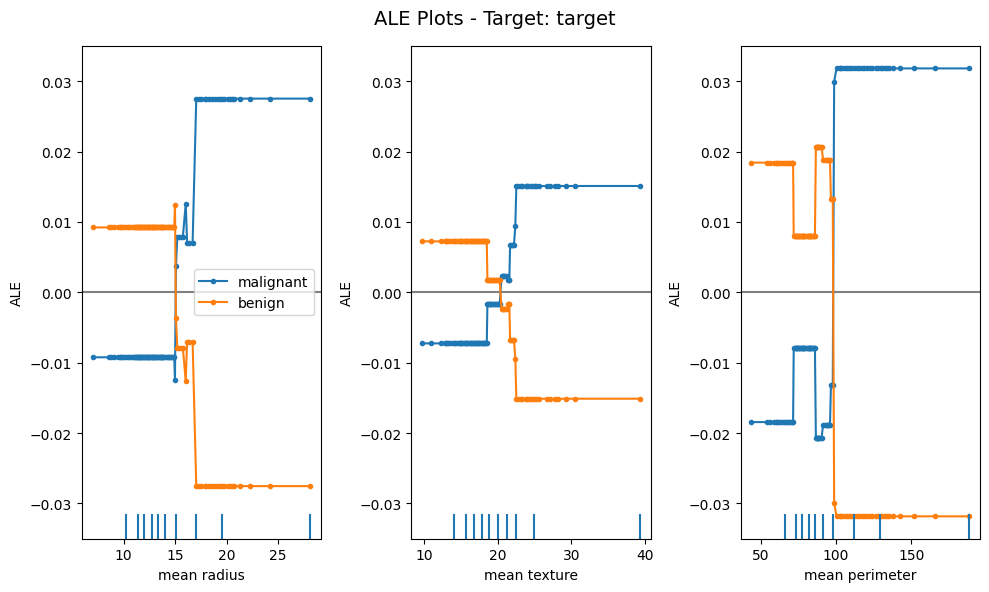

In [ ]:
# Fix for NumPy 2.x compatibility with older alibi version
if not hasattr(np, "object"):
    np.object = object

# Dictionary to store ALE explanations across targets
ale_explanations = {}

# Iterate dynamically over each target
for current_target in targets:

    # Update unified payload for the active target
    unified_payload["target"] = df[current_target]
    unified_payload["metadata"]["active_target"] = current_target

    # Execute only if the explanation scope is global or both
    if unified_payload["scope"] in ["global", "both"]:

        # Determine prediction function dynamically based on task type
        if task_type == "classification":
            # ALE expects class probability outputs for classification tasks
            predict_fn = lambda x: model.predict_proba(pd.DataFrame(x, columns=feature_names))
        else:
            # ALE expects continuous outputs for regression tasks
            predict_fn = lambda x: model.predict(pd.DataFrame(x, columns=feature_names))

        # Initialize the ALE explainer
        ale_explainer = ALE(
            predictor=predict_fn,
            feature_names=feature_names,
            target_names=unified_payload["metadata"].get("class_names", None)
        )

        # Compute Accumulated Local Effects across the training dataset
        ale_exp = ale_explainer.explain(X_np)

        # Store explanation object in the dictionary
        ale_explanations[current_target] = ale_exp

        # Select features to visualize (e.g., top features or a user-defined subset)
        features_to_plot = feature_names[:3]

        # Generate and render ALE plots
        fig, ax = plt.subplots(figsize=(10, 6))
        plot_ale(ale_exp, features=features_to_plot, ax=ax)
        plt.suptitle(f"ALE Plots - Target: {current_target}", fontsize=14)
        plt.tight_layout()
        plt.show()

## 3.7 PFI

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


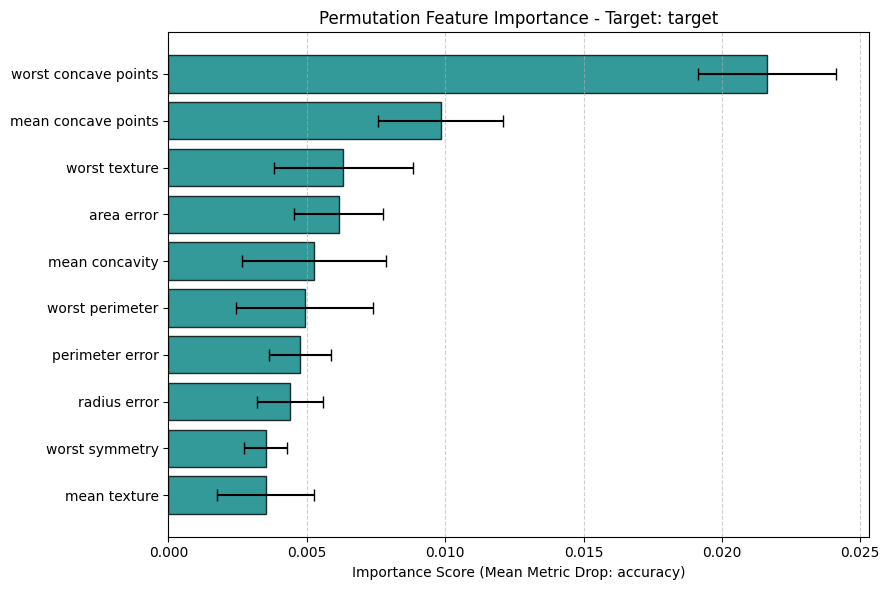


--- Top Feature Importances (Target: target) ---
 1. worst concave points      Mean: 0.0216 +/- 0.0025
 2. mean concave points       Mean: 0.0098 +/- 0.0023
 3. worst texture             Mean: 0.0063 +/- 0.0025
 4. area error                Mean: 0.0062 +/- 0.0016
 5. mean concavity            Mean: 0.0053 +/- 0.0026
 6. worst perimeter           Mean: 0.0049 +/- 0.0025
 7. perimeter error           Mean: 0.0047 +/- 0.0011
 8. radius error              Mean: 0.0044 +/- 0.0012
 9. worst symmetry            Mean: 0.0035 +/- 0.0008
10. mean texture              Mean: 0.0035 +/- 0.0018


In [ ]:
# Dictionary to store PFI explanation objects across targets
pfi_explanations = {}

# Iterate dynamically over each target
for current_target in targets:

    # Update unified payload for the active target
    unified_payload["target"] = df[current_target]
    unified_payload["metadata"]["active_target"] = current_target

    # Execute only if the explanation scope is global or both
    if unified_payload["scope"] in ["global", "both"]:

        # Retrieve user-defined scoring metric or fallback dynamically based on task type
        user_metric = unified_payload["metadata"].get("scoring_metric")
        if user_metric is not None:
            active_scoring = user_metric
        else:
            active_scoring = (
                "accuracy"
                if unified_payload["metadata"]["task_type"] == "classification"
                else "r2"
            )

        # Compute Permutation Feature Importance
        pfi_result = permutation_importance(
            estimator=model,
            X=X_np,
            y=unified_payload["target"].values,
            scoring=active_scoring,
            n_repeats=10,
            random_state=42,
            n_jobs=-1
        )

        # Store explanation object in dictionary
        pfi_explanations[current_target] = pfi_result

        # Sort features by mean importance in descending order
        sorted_indices = pfi_result.importances_mean.argsort()[::-1]
        sorted_features = [feature_names[i] for i in sorted_indices]
        sorted_means = pfi_result.importances_mean[sorted_indices]
        sorted_stds = pfi_result.importances_std[sorted_indices]

        # Select top features for visualization (e.g., top 10)
        top_k = min(10, len(feature_names))
        top_features = sorted_features[:top_k][::-1]
        top_means = sorted_means[:top_k][::-1]
        top_stds = sorted_stds[:top_k][::-1]

        # Visualize Permutation Feature Importance with standard deviation bars
        plt.figure(figsize=(9, 6))
        plt.barh(
            top_features,
            top_means,
            xerr=top_stds,
            color="teal",
            edgecolor="black",
            alpha=0.8,
            capsize=4
        )
        plt.xlabel(f"Importance Score (Mean Metric Drop: {active_scoring})")
        plt.title(f"Permutation Feature Importance - Target: {current_target}", fontsize=12)
        plt.grid(axis="x", linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

        # Print top feature importance summary
        print(f"\n--- Top Feature Importances (Target: {current_target}) ---")
        for rank, (name, mean_val, std_val) in enumerate(
            zip(sorted_features[:top_k], sorted_means[:top_k], sorted_stds[:top_k]), 1
        ):
            print(f"{rank:2d}. {name:<25} Mean: {mean_val:.4f} +/- {std_val:.4f}")

## 3.8 Partial Dependence and Individual Conditional Expectation Plots (PDP/ICE)


================ PDP / ICE ================
Target: target
Task type: classification
Selected features: ['worst concave points', 'mean concave points', 'mean perimeter', 'mean concavity', 'worst perimeter', 'mean radius']

Computing Partial Dependence plots...


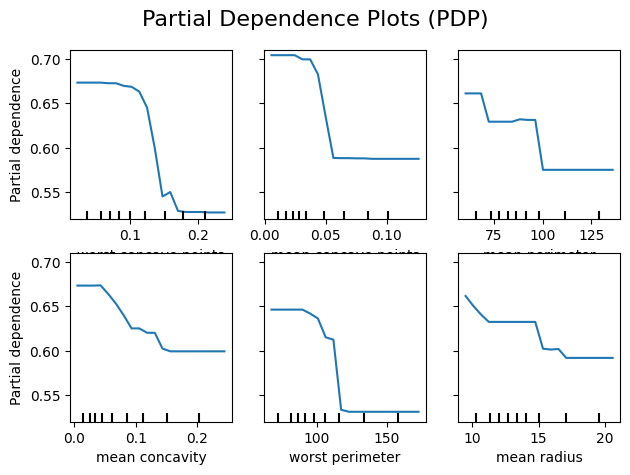


Computing ICE + PDP plots...


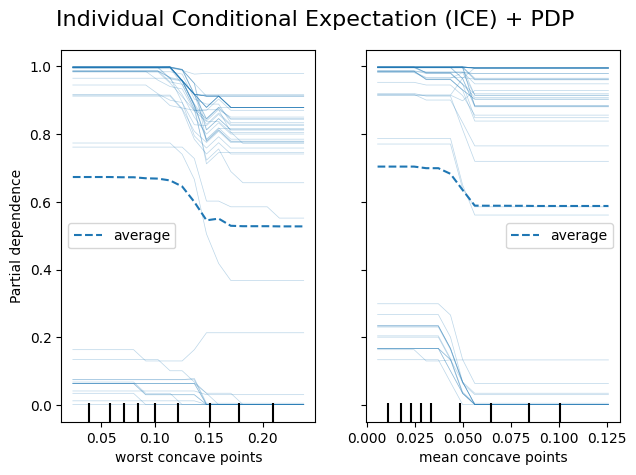


[✓] PDP / ICE explanation completed.


In [ ]:
pdp_ice_explanations = {}

for current_target in targets:

    # Update unified payload for the active target
    unified_payload["target"] = df[current_target]
    unified_payload["metadata"]["active_target"] = current_target

    if unified_payload["scope"] in ["global", "both"]:

        # ----------------------------------------------------
        # 1. Select features
        # ----------------------------------------------------

        configured_features = unified_payload["metadata"]["features_to_plot"]

        if configured_features is not None:

            selected_features = [
                feature
                for feature in configured_features
                if feature in feature_names
            ]

        else:

            # Automatically select the most important features
            if hasattr(model, "feature_importances_"):

                importance_df = pd.DataFrame({
                    "feature": feature_names,
                    "importance": model.feature_importances_
                }).sort_values(
                    by="importance",
                    ascending=False
                )

                selected_features = (
                    importance_df
                    .head(6)["feature"]
                    .tolist()
                )

            else:

                selected_features = feature_names[:6]


        print("\n================ PDP / ICE ================")
        print(f"Target: {current_target}")
        print(f"Task type: {task_type}")
        print(f"Selected features: {selected_features}")


        # ----------------------------------------------------
        # 2. Define parameters according to task type
        # ----------------------------------------------------

        pdp_parameters = {
            "estimator": model,
            "X": df_ref,
            "features": selected_features,
            "grid_resolution": 20,
            "subsample": 50,
            "random_state": unified_payload["metadata"]["random_state"]
        }

        if task_type == "classification":

            pdp_parameters["response_method"] = "predict_proba"


        elif task_type == "regression":

            # For regression, sklearn uses predict()
            # No response_method is required.

            pass

        else:

            raise ValueError(
                f"Unsupported task type: {task_type}"
            )


        # ----------------------------------------------------
        # 3. Partial Dependence Plot (PDP)
        # ----------------------------------------------------

        print("\nComputing Partial Dependence plots...")

        pdp_display = PartialDependenceDisplay.from_estimator(
            **pdp_parameters,
            kind="average"
        )

        pdp_display.figure_.suptitle(
            "Partial Dependence Plots (PDP)",
            fontsize=16
        )

        plt.tight_layout()
        plt.show()


        # ----------------------------------------------------
        # 4. ICE + PDP
        # ----------------------------------------------------

        print("\nComputing ICE + PDP plots...")

        # Use the two most important features for ICE
        # to keep the visualization readable.

        ice_features = selected_features[:2]

        ice_parameters = {
            "estimator": model,
            "X": df_ref,
            "features": ice_features,
            "kind": "both",
            "centered": False,
            "grid_resolution": 20,
            "subsample": 50,
            "random_state": unified_payload["metadata"]["random_state"]
        }

        if task_type == "classification":

            ice_parameters["response_method"] = "predict_proba"


        elif task_type == "regression":

            # Regression uses model.predict()
            pass


        ice_display = PartialDependenceDisplay.from_estimator(
            **ice_parameters
        )

        ice_display.figure_.suptitle(
            "Individual Conditional Expectation (ICE) + PDP",
            fontsize=16
        )

        plt.tight_layout()
        plt.show()


        # ----------------------------------------------------
        # 5. Store explanations
        # ----------------------------------------------------

        pdp_ice_explanations[current_target] = {
            "selected_features": selected_features,
            "ice_features": ice_features,
            "pdp_display": pdp_display,
            "ice_display": ice_display,
            "task_type": task_type
        }

        print("\n[✓] PDP / ICE explanation completed.")

## 3.9 Integrated Gradients

Target: target
Task type: classification
IG model: PyTorch surrogate
Original model classes: [0 1]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


[✓] Surrogate model trained.

Top feature attributions:
        feature  attribution  absolute_attribution
     worst area   -43.267380             43.267380
      mean area    10.377045             10.377045
worst perimeter     9.751952              9.751952
 mean perimeter     5.770218              5.770218
     area error    -5.423225              5.423225
    mean radius     0.876113              0.876113
perimeter error    -0.242774              0.242774
   mean texture    -0.228046              0.228046
   worst radius     0.168834              0.168834
  worst texture    -0.141299              0.141299

Convergence delta: -0.000105
Explained output: Binary classification output


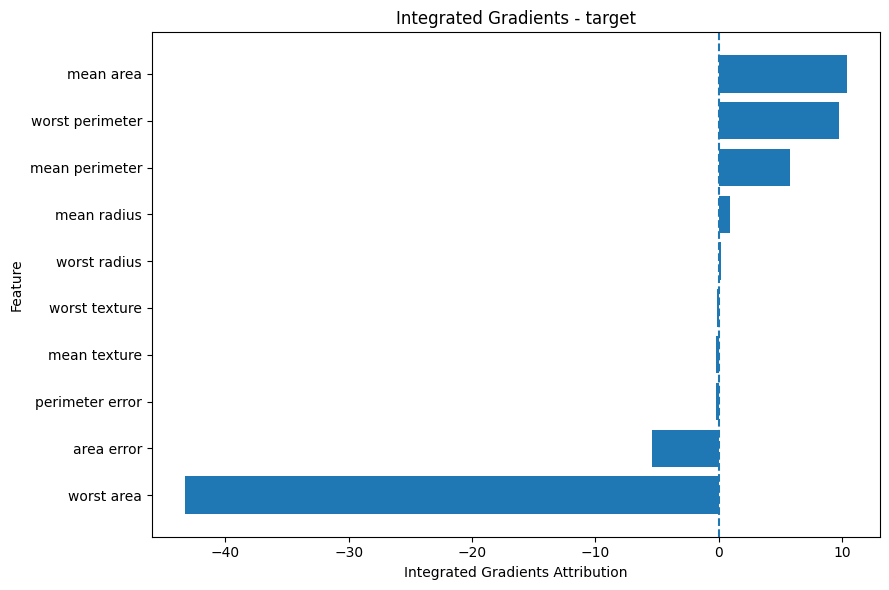


Global Average Feature Importance:
        feature  mean_absolute_attribution
     worst area                  24.816055
      mean area                   9.838400
 mean perimeter                   6.318601
worst perimeter                   6.246306
     area error                   1.244543
    mean radius                   0.658466
   worst radius                   0.568033
  worst texture                   0.264772
   mean texture                   0.204161
worst concavity                   0.044343


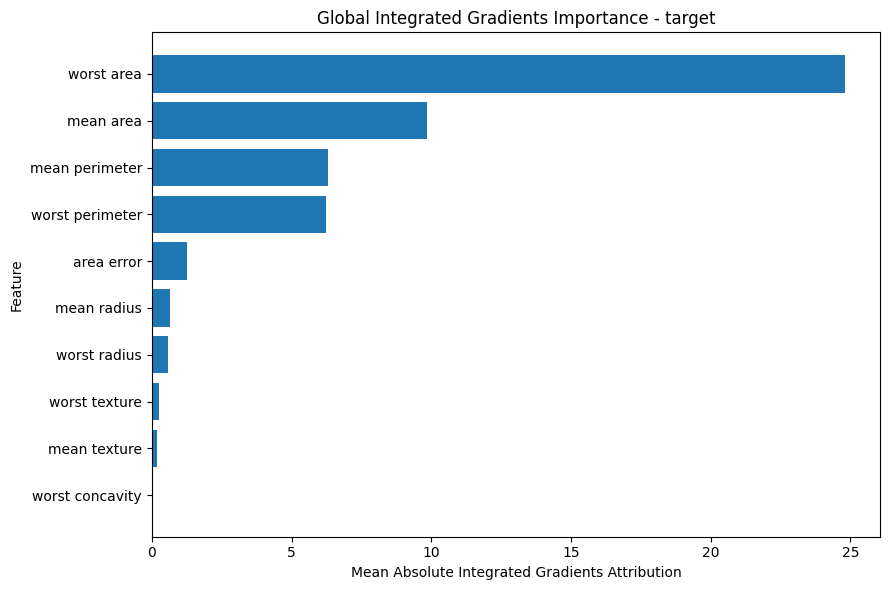


[✓] Integrated Gradients explanation completed.


In [ ]:
# Supports:
#   1. Direct PyTorch models
#   2. Non-differentiable models via PyTorch surrogate
#   3. Binary classification
#   4. Multiclass classification
#   5. Regression

from captum.attr import IntegratedGradients
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Helper 1: Check whether a model is a PyTorch model

def is_pytorch_model(model):
    return isinstance(model, torch.nn.Module)

# Helper 2: Generic tabular PyTorch surrogate

class TabularSurrogate(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim=1
    ):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.network(x)

# Storage
integrated_gradients_explanations = {}

# Iterate over targets

for current_target in targets:

    # Update unified payload

    unified_payload["target"] = df[current_target]

    unified_payload["metadata"]["active_target"] = (
        current_target
    )

    print(f"Target: {current_target}")
    print(f"Task type: {task_type}")


    # 1. Determine the model used for IG
    if ig_model is not None:
        # User explicitly provided a model for IG
        ig_estimator = ig_model
        using_surrogate = False
        print("IG model: User-provided model")

    elif is_pytorch_model(model):
        # Main model is already a PyTorch model
        ig_estimator = model
        using_surrogate = False
        print("IG model: Main PyTorch model")

    else:
        # Main model is not differentiable
        if not ig_use_surrogate:
            print(
                "\n[!] Integrated Gradients skipped."
            )
            print(
                "The supplied model is not a differentiable "
                "PyTorch model and surrogate mode is disabled."
            )
            continue
        # Use surrogate
        print(
            "IG model: PyTorch surrogate"
        )

        using_surrogate = True

        # 2. Prepare surrogate training data
        X_surrogate = np.asarray(
            df_ref
        )

        X_surrogate_tensor = torch.tensor(
            X_surrogate,
            dtype=torch.float32
        )

        # 3. Get predictions from original model
        if task_type == "classification":
            # We use class predictions for the surrogate.
            y_original = model.predict(
                X_surrogate
            )
            classes = np.unique(
                y_original
            )
            n_classes = len(classes)
            print(
                f"Original model classes: {classes}"
            )

        elif task_type == "regression":
            y_original = model.predict(
                X_surrogate
            )
            y_original = np.asarray(
                y_original
            ).reshape(-1)
            n_classes = None
        else:
            raise ValueError(
                f"Unsupported task type: {task_type}"
            )

        # 4. Create surrogate
        if task_type == "classification":
            if n_classes == 2:
                # Binary classification
                output_dim = 1
            else:
                # Multiclass classification
                output_dim = n_classes
        else:
            # Regression
            output_dim = 1
        ig_estimator = TabularSurrogate(
            input_dim=X_surrogate.shape[1],
            output_dim=output_dim
        )

        # 5. Prepare surrogate target
        if task_type == "regression":
            y_tensor = torch.tensor(
                y_original,
                dtype=torch.float32
            ).reshape(-1, 1)
            loss_function = nn.MSELoss()
        else:
            # Convert original class labels to indices
            class_to_index = {
                cls: idx
                for idx, cls in enumerate(classes)
            }
            y_indices = np.array([

                class_to_index[y]

                for y in y_original

            ])
            if n_classes == 2:
                # Binary classification
                y_tensor = torch.tensor(
                    y_indices,
                    dtype=torch.float32
                ).reshape(-1, 1)
                loss_function = (
                    nn.BCEWithLogitsLoss()
                )
            else:
                # Multiclass classification
                y_tensor = torch.tensor(
                    y_indices,
                    dtype=torch.long
                )
                loss_function = (
                    nn.CrossEntropyLoss()
                )
        # 6. Train surrogate
        optimizer = torch.optim.Adam(
            ig_estimator.parameters(),
            lr=0.001
        )
        ig_estimator.train()
        n_epochs = 300
        for epoch in range(n_epochs):
            optimizer.zero_grad()
            surrogate_output = (
                ig_estimator(
                    X_surrogate_tensor
                )
            )
            if task_type == "classification":
                if n_classes == 2:
                    loss = loss_function(
                        surrogate_output,
                        y_tensor
                    )
                else:
                    loss = loss_function(
                        surrogate_output,
                        y_tensor
                    )
            else:
                loss = loss_function(
                    surrogate_output,
                    y_tensor
                )
            loss.backward()
            optimizer.step()
        ig_estimator.eval()
        print(
            "[✓] Surrogate model trained."
        )
    # 7. Prepare observation to explain
    x_input = np.asarray(
        x_1d
    ).reshape(1, -1)
    x_tensor = torch.tensor(
        x_input,
        dtype=torch.float32
    )
    # 8. Define baseline
    if ig_baseline == "zero":
        baseline_tensor = torch.zeros_like(
            x_tensor
        )
    elif ig_baseline == "mean":
        mean_values = np.asarray(
            df_ref.mean(axis=0)
        ).reshape(1, -1)
        baseline_tensor = torch.tensor(
            mean_values,
            dtype=torch.float32
        )
    else:
        raise ValueError(
            "ig_baseline must be 'zero' or 'mean'."
        )
    # 9. Determine classification target
    ig_target = None
    if task_type == "classification":
        with torch.no_grad():
            model_output = (
                ig_estimator(
                    x_tensor
                )
            )
        # Binary classification
        if model_output.shape[-1] == 1:
            # Captum does not need a class target for
            # a single-output model.
            ig_target = None
        # Multiclass classification
        else:
            if ig_target_class is not None:
                ig_target = (
                    ig_target_class
                )
            else:
                ig_target = int(
                    torch.argmax(
                        model_output,
                        dim=1
                    ).item()
                )
    # 10. Integrated Gradients
    ig = IntegratedGradients(
        ig_estimator
    )
    attributions, convergence_delta = (
        ig.attribute(
            x_tensor,
            baselines=baseline_tensor,
            target=ig_target,
            n_steps=ig_n_steps,
            return_convergence_delta=True
        )
    )
    # 11. Convert attributions to DataFrame
    attribution_values = (
        attributions
        .detach()
        .cpu()
        .numpy()
        .flatten()
    )
    attribution_df = pd.DataFrame({
        "feature":
            feature_names,
        "attribution":
            attribution_values,
        "absolute_attribution":
            np.abs(attribution_values)
    })
    attribution_df = (
        attribution_df
        .sort_values(
            by="absolute_attribution",
            ascending=False
        )
        .reset_index(drop=True)
    )
    # 12. Print results
    print("\nTop feature attributions:")
    print(
        attribution_df
        .head(10)
        .to_string(index=False)
    )
    delta_value = (
        convergence_delta
        .detach()
        .cpu()
        .numpy()
        .flatten()[0]
    )
    print(
        f"\nConvergence delta: "
        f"{delta_value:.6f}"
    )
    if task_type == "classification":
        if ig_target is not None:
            print(
                f"Explained class index: "
                f"{ig_target}"
            )
        else:
            print(
                "Explained output: "
                "Binary classification output"
            )
    # 13. Visualization
    top_n = min(
        10,
        len(attribution_df)
    )
    plot_df = (
        attribution_df
        .head(top_n)
        .sort_values(
            "attribution"
        )
    )
    plt.figure(
        figsize=(9, 6)
    )
    plt.barh(
        plot_df["feature"],
        plot_df["attribution"]
    )
    plt.axvline(
        0,
        linestyle="--"
    )
    plt.xlabel(
        "Integrated Gradients Attribution"
    )
    plt.ylabel(
        "Feature"
    )
    plt.title(
        f"Integrated Gradients - "
        f"{current_target}"
    )
    plt.tight_layout()
    plt.show()

    # 13b. Global Integrated Gradients Importance
    global_importance_df=None

    if ig_compute_global_importance:
        X_global=np.asarray(df_ref[feature_names],dtype=np.float32)
        if ig_global_n_samples is not None and ig_global_n_samples<len(X_global):
            rng=np.random.default_rng(unified_payload["metadata"]["random_state"])
            idx=rng.choice(len(X_global),ig_global_n_samples,replace=False)
            X_global=X_global[idx]

        X_global_tensor=torch.tensor(X_global,dtype=torch.float32)

        if ig_baseline=="zero":
            global_baseline=torch.zeros_like(X_global_tensor)
        else:
            mean_values=np.asarray(df_ref.mean(axis=0),dtype=np.float32).reshape(1,-1)
            global_baseline=torch.tensor(mean_values,dtype=torch.float32).repeat(len(X_global_tensor),1)

        if task_type=="classification":
            output=ig_estimator(X_global_tensor)
            if output.shape[-1]==1:
                global_target=None
            elif ig_target_class is not None:
                global_target=ig_target_class
            else:
                global_target=torch.argmax(output,dim=1)
        else:
            global_target=None

        if task_type=="classification" and output.shape[-1]>1 and ig_target_class is None:
            attrs=[]
            for i in range(len(X_global_tensor)):
                a=ig.attribute(X_global_tensor[i:i+1],
                              baselines=global_baseline[i:i+1],
                              target=int(global_target[i]),
                              n_steps=ig_n_steps)
                attrs.append(a.detach().cpu().numpy().flatten())
            global_attrs=np.asarray(attrs)
        else:
            global_attrs=ig.attribute(X_global_tensor,
                                      baselines=global_baseline,
                                      target=global_target,
                                      n_steps=ig_n_steps).detach().cpu().numpy()

        global_importance_df=pd.DataFrame({
            "feature":feature_names,
            "mean_absolute_attribution":np.mean(np.abs(global_attrs),axis=0)
        }).sort_values("mean_absolute_attribution",ascending=False).reset_index(drop=True)

        print("\nGlobal Average Feature Importance:")
        print(global_importance_df.head(ig_global_top_k).to_string(index=False))

        plot_df=global_importance_df.head(ig_global_top_k).sort_values("mean_absolute_attribution")
        plt.figure(figsize=(9,6))
        plt.barh(plot_df["feature"],plot_df["mean_absolute_attribution"])
        plt.xlabel("Mean Absolute Integrated Gradients Attribution")
        plt.ylabel("Feature")
        plt.title(f"Global Integrated Gradients Importance - {current_target}")
        plt.tight_layout()
        plt.show()


    # 14. Store explanation
    integrated_gradients_explanations[
        current_target
    ] = {
        "attributions": attribution_df,
        "convergence_delta": delta_value,
        "target_class": ig_target,
        "baseline": ig_baseline,
        "n_steps": ig_n_steps,
        "using_surrogate": using_surrogate,
        "ig_model": ig_estimator,
        "global_importance": global_importance_df
    }
    print(
        "\n[✓] Integrated Gradients "
        "explanation completed."
    )